In [1]:
# @title { vertical-output: true}

import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !pip install numpy matplotlib myplotlib sympy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 3.7 MB/s eta 0:00:00


In [2]:
# @title { vertical-output: true}


import logging
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.patheffects as mpatheffects
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from myplotlib import register
import myplotlib.plots as myplt
import sympy as sp

register()

plt.style.use("guttenberg.light")


class _P22WeightWarningFilter(logging.Filter):
    def filter(self, record):
        return "findfont" not in record.getMessage()


logging.getLogger("matplotlib.font_manager").addFilter(_P22WeightWarningFilter())

In [3]:
# @title { vertical-output: true}

# Figure parameters


class Parameters:
    class Common:
        C0 = "#3e6fb5"
        C1 = "#b2252a"
        C2 = "#6f8f5e"
        C4 = "#974F9C"

    class Orbit:
        r0 = 1
        r = 1.2
        R = 5
        GM = 11
        L1 = 1.5
        L3 = 2.5


# Common functions


def U(radius, ll):
    return ll**2 / (2 * radius**2) - Parameters.Orbit.GM / radius


def V(radius, ll):
    return np.sqrt(2 * (U(radius, ll) + Parameters.Orbit.GM / radius))


def Lmax(rmin):
    return np.sqrt(2 * Parameters.Orbit.GM * rmin)


def Rmax(rmin, ll):
    return rmin / (2 * Parameters.Orbit.GM * rmin / ll**2 - 1)


def r_from_L(L):
    return L**2 / Parameters.Orbit.GM


def L_from_rmin_rmax(rmin, rmax):
    return np.sqrt(2 * Parameters.Orbit.GM / (1 / rmin + 1 / rmax))


def xmark(ax, x, y, size, **kwargs):
    ax.plot(
        [x - size, x + size],
        [y - size, y + size],
        **kwargs,
    )
    ax.plot(
        [x - size, x + size],
        [y + size, y - size],
        **kwargs,
    )


def arrowed_spines(fig, ax):

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # removing the default axis on all sides:
    for side in ["bottom", "right", "top", "left"]:
        ax.spines[side].set_visible(False)

    # removing the axis ticks
    plt.xticks([])  # labels
    plt.yticks([])
    ax.xaxis.set_ticks_position("none")  # tick markers
    ax.yaxis.set_ticks_position("none")

    # get width and height of axes object to compute
    # matching arrowhead length and width
    dps = fig.dpi_scale_trans.inverted()
    bbox = ax.get_window_extent().transformed(dps)
    width, height = bbox.width, bbox.height

    # manual arrowhead width and length
    hw = 1.0 / 40.0 * (ymax - ymin)
    hl = 1.0 / 40.0 * (xmax - xmin)
    lw = 1.0  # axis line width
    ohg = 0.1  # arrow overhang

    # compute matching arrowhead length and width
    yhw = hw / (ymax - ymin) * (xmax - xmin) * height / width
    yhl = hl / (xmax - xmin) * (ymax - ymin) * width / height

    # draw x and y axis
    ax.arrow(
        xmin,
        0,
        xmax - xmin,
        0.0,
        fc="k",
        ec="k",
        lw=lw,
        head_width=hw,
        head_length=hl,
        overhang=ohg,
        length_includes_head=True,
        clip_on=False,
    )

    ax.arrow(
        0,
        ymin,
        0.0,
        ymax - ymin,
        fc="k",
        ec="k",
        lw=lw,
        head_width=yhw,
        head_length=yhl,
        overhang=ohg,
        length_includes_head=True,
        clip_on=False,
    )

# Орбитальные парадоксы

Вывод искусственных спутников на орбиту вокруг Земли -- очень энергозатратное мероприятие. К примеру, в среднем, на вывод 1 кг груза на низкую околоземную орбиту тратится порядка 100 МДж энергии, что сравнимо со средним потреблением энергии небольшого дома в течение одного дня (порядка 30 кВт$\cdot$ч). При этом, большая часть массы корабля составляет топливо: даже для самых эффективных носителей, отношение массы полезного груза к полной массе корабля при запуске редко превышает 5%. Картина становится ещё сложнее, если корабль выводится не на низкую околоземную орбиту, а более далёкую (например, геостационарную [ССЫЛКА]).

В случае вывода на более далёкие орбиты, гораздо экономнее, с точки зрения расхода топлива, совершать манёвр ускорения в несколько этапов. В этой задаче мы рассмотрим упрощённые примеры нескольких таких манёвров, и посчитаем теоретический расход топлива в каждом из этих случаев.

## Задача

Для начала, рассмотрим манёвр вывода корабля с более низкой орбиты на более высокую -- т.н. гомановская траектория, названная в честь немецкого учёного начала XX века Вальтера Гомана. На Рис. 1 показаны начальная (синим) и конечная (зелёным) круговые траектории корабля, которые имеют радиус, соответственно, $r$ и $R$. В первом манёвре, корабль должен сперва ускориться с тракетории #1 до эллиптической траектории #2 (красным) в точке $A$, и только после ускориться с траектории #2 до финальной траектории #3 в точке $B$.

**Найдите минимальную долю топлива (относительно полной массы корабля на низкой орбите), необходимую для такого манёвра. Также посчитайте необходимую корректировку скорости корабля, $\Delta v_A$ и $\Delta v_B$, в точках этапов ускорения $A$ и $B$.**

Для оценки, считайте что скорость истечения топлива относительно корабля -- $v_0$, а скорость корабля на низкой околоземной орбите -- $v_\oplus\equiv \sqrt{GM/r}$ (где $M$ -- масса Земли, а $G$ -- гравитационная постоянная). Для простоты, считайте, что ускорение корабля происходит моментально (иными словами, время работы двигателей много меньше периода траектории). Подставьте соответствующие значения для Земной орбиты; примите $v_0\approx 4$ км/с.

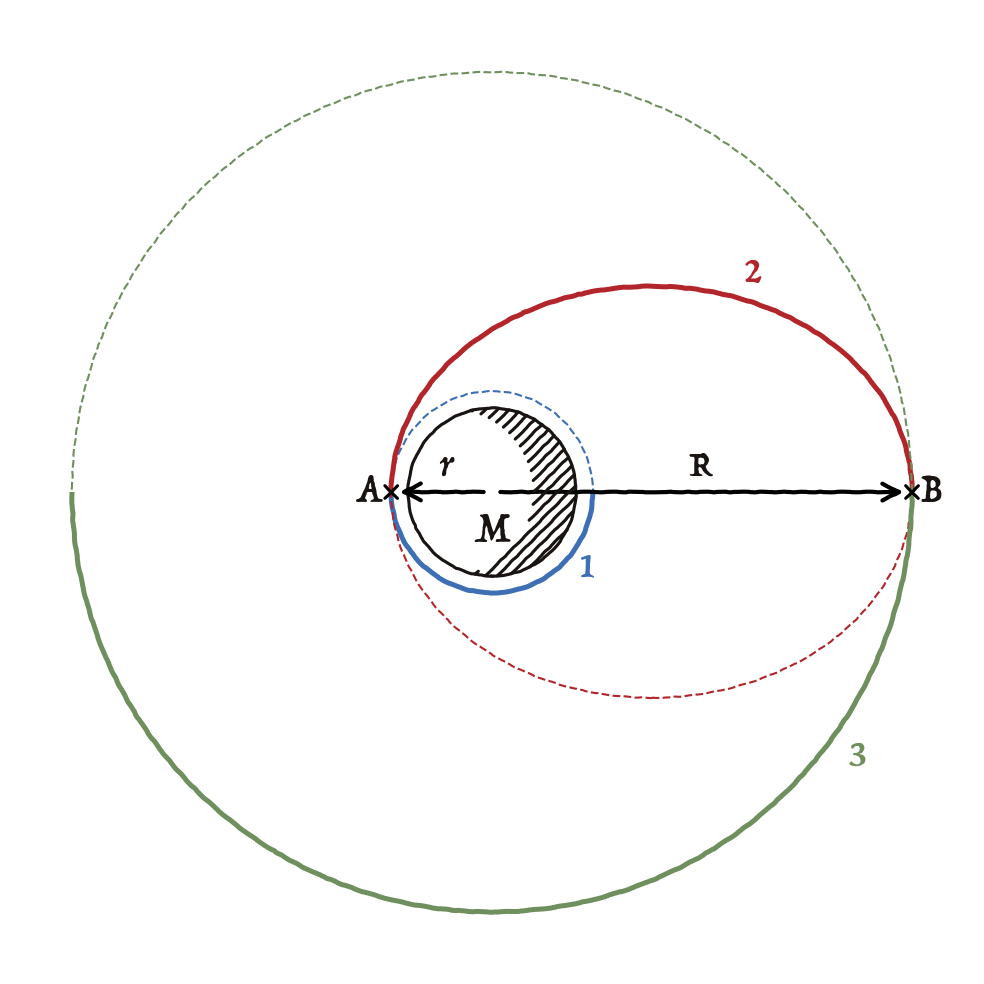

In [4]:
# @title { vertical-output: true}


class Scratch:
    e = (Parameters.Orbit.R - Parameters.Orbit.r) / (
        Parameters.Orbit.R + Parameters.Orbit.r
    )
    a = (Parameters.Orbit.R + Parameters.Orbit.r) / 2
    b = np.sqrt(Parameters.Orbit.R * Parameters.Orbit.r)


fig = plt.figure(figsize=(4, 4), dpi=300)
ax = fig.add_subplot(111)

myplt.hatchedCircle(
    ax,
    (0, 0),
    Parameters.Orbit.r0,
    shade_from=180,
    shade_depth=0.5,
    spacing=0.1,
    linewidth=0.75,
)
ax.add_artist(
    mpatches.Circle(
        (0, 0),
        Parameters.Orbit.r,
        fill=False,
        color=Parameters.Common.C0,
        linewidth=0.5,
        ls="--",
    )
)
ax.add_artist(
    mpatches.Arc(
        (0, 0),
        Parameters.Orbit.r * 2,
        Parameters.Orbit.r * 2,
        theta1=180,
        theta2=0,
        color=Parameters.Common.C0,
        linewidth=1.2,
        ls="-",
    )
)
ax.add_artist(
    mpatches.Ellipse(
        (
            -Parameters.Orbit.r + (Parameters.Orbit.R + Parameters.Orbit.r) / 2,
            0,
        ),
        Scratch.a * 2,
        Scratch.b * 2,
        fill=False,
        color=Parameters.Common.C1,
        linewidth=0.5,
        ls="--",
    )
)
ax.add_artist(
    mpatches.Arc(
        (
            -Parameters.Orbit.r + (Parameters.Orbit.R + Parameters.Orbit.r) / 2,
            0,
        ),
        Scratch.a * 2,
        Scratch.b * 2,
        theta1=0,
        theta2=180,
        color=Parameters.Common.C1,
        linewidth=1.2,
        ls="-",
    )
)
ax.add_artist(
    mpatches.Circle(
        (0, 0),
        Parameters.Orbit.R,
        fill=False,
        color=Parameters.Common.C2,
        linewidth=0.5,
        ls="--",
    )
)
ax.add_artist(
    mpatches.Arc(
        (0, 0),
        Parameters.Orbit.R * 2,
        Parameters.Orbit.R * 2,
        theta1=180,
        theta2=0,
        color=Parameters.Common.C2,
        linewidth=1.2,
        ls="-",
    )
)

arr_r = mpatches.FancyArrowPatch(
    (0, 0),
    (-Parameters.Orbit.r, 0),
    arrowstyle="->",
    mutation_scale=10,
)
ax.add_artist(arr_r)
ax.annotate("r", (0.5, 0.5), xycoords=arr_r, ha="center", va="bottom")
arr_R = mpatches.FancyArrowPatch(
    (0, 0),
    (Parameters.Orbit.R, 0),
    arrowstyle="->",
    mutation_scale=10,
)
ax.add_artist(arr_R)
ax.annotate("R", (0.5, 0.5), xycoords=arr_R, ha="center", va="bottom")
ax.text(-Parameters.Orbit.r - 0.1, 0, "A", ha="right", va="center", fontsize="large")
ax.text(Parameters.Orbit.R + 0.1, 0, "B", ha="left", va="center", fontsize="large")
xmark(ax, -Parameters.Orbit.r, 0, 0.075, c="k", lw=0.75, ls="-")
xmark(ax, Parameters.Orbit.R, 0, 0.075, c="k", lw=0.75, ls="-")

ax.text(1, -1, "1", c=Parameters.Common.C0)
ax.text(3, 2.5, "2", c=Parameters.Common.C1)
ax.text(4.25, -3.25, "3", c=Parameters.Common.C2)
ax.text(0, -0.1, r"$M$", ha="center", va="top", fontsize="large")

ax.set(xlim=(-5.5, 5.5), ylim=(-5.5, 5.5), aspect=1)
ax.axis("off");

Рис. 1: Схематическая иллюстрация орбит в процессе гомановского манёвра в различных стадиях движения корабля начиная от круговой орбиты радиусом $r$ до круговой орбиты радиусом $R$. Манёвр включает в себя два этапа ускорения в точках $A$ и $B$. Цельными линиями показана последовательность полёта корабля.

Удобно изобразить гомановский манёвр на графике для эффективного потенциала (Рис. 2):

$$
\mathcal{U}(r) = \frac{\mathcal{L}}{2mr^2} - \frac{GMm}{r},
$$

где $\mathcal{L}$ соответствует сохраняющемуся моменту импульса вдоль каждой траектории. Об этом графике можно думать следующим образом: любая траектория вокруг объекта массы $M$ определяется двумя сохраняющимися вдоль траектории величинами (т.н. интегралами движения) -- полной энергией, $\mathcal{E}$, и моментом импульса, $\mathcal{L}$. Значение момента импульса однозначно определяет кривую эффективного потенциала, $\mathcal{U}(r)$, тогда как значение полной энергии определяет по какой траектории вдоль этой кривой движется тело; в точках минимального и максимального удаления, значение потенциала в точности равно значению полной энергии: $\mathcal{U}(r) = \mathcal{U}(R) = \mathcal{E}$. В случае, когда $r=R$, движение происходит по круговой орбите, что соответствует минимально возможной энергии для фиксированного значения $\mathcal{L}$.

Траектории #1, #2 и #3 из Рис. 1 показаны соответствующими цветами на Рис. 2. Таким образом, манёвр включает в себя два этапа изменения энергии, $\Delta\mathcal{E}_A$ и $\Delta\mathcal{E}_B$, в результате чего корабль выходит на круговую орбиту. Заметим, что вне зависимости от деталей манёвра (к примеру, можно сделать то же самое в несколько ускорений), сумма изменения энергий в результате всегда фиксирована: $\Delta\mathcal{E}_A + \Delta\mathcal{E}_B = \mathcal{E}_3 - \mathcal{E}_1$. На Рис. 2 справа показана похожая диаграма, только по оси $y$ отложена скорость движения корабля.

Отсюда возникает вопрос:

**Можно ли придумать более эффективную траекторию с точки зрения расхода топлива?**

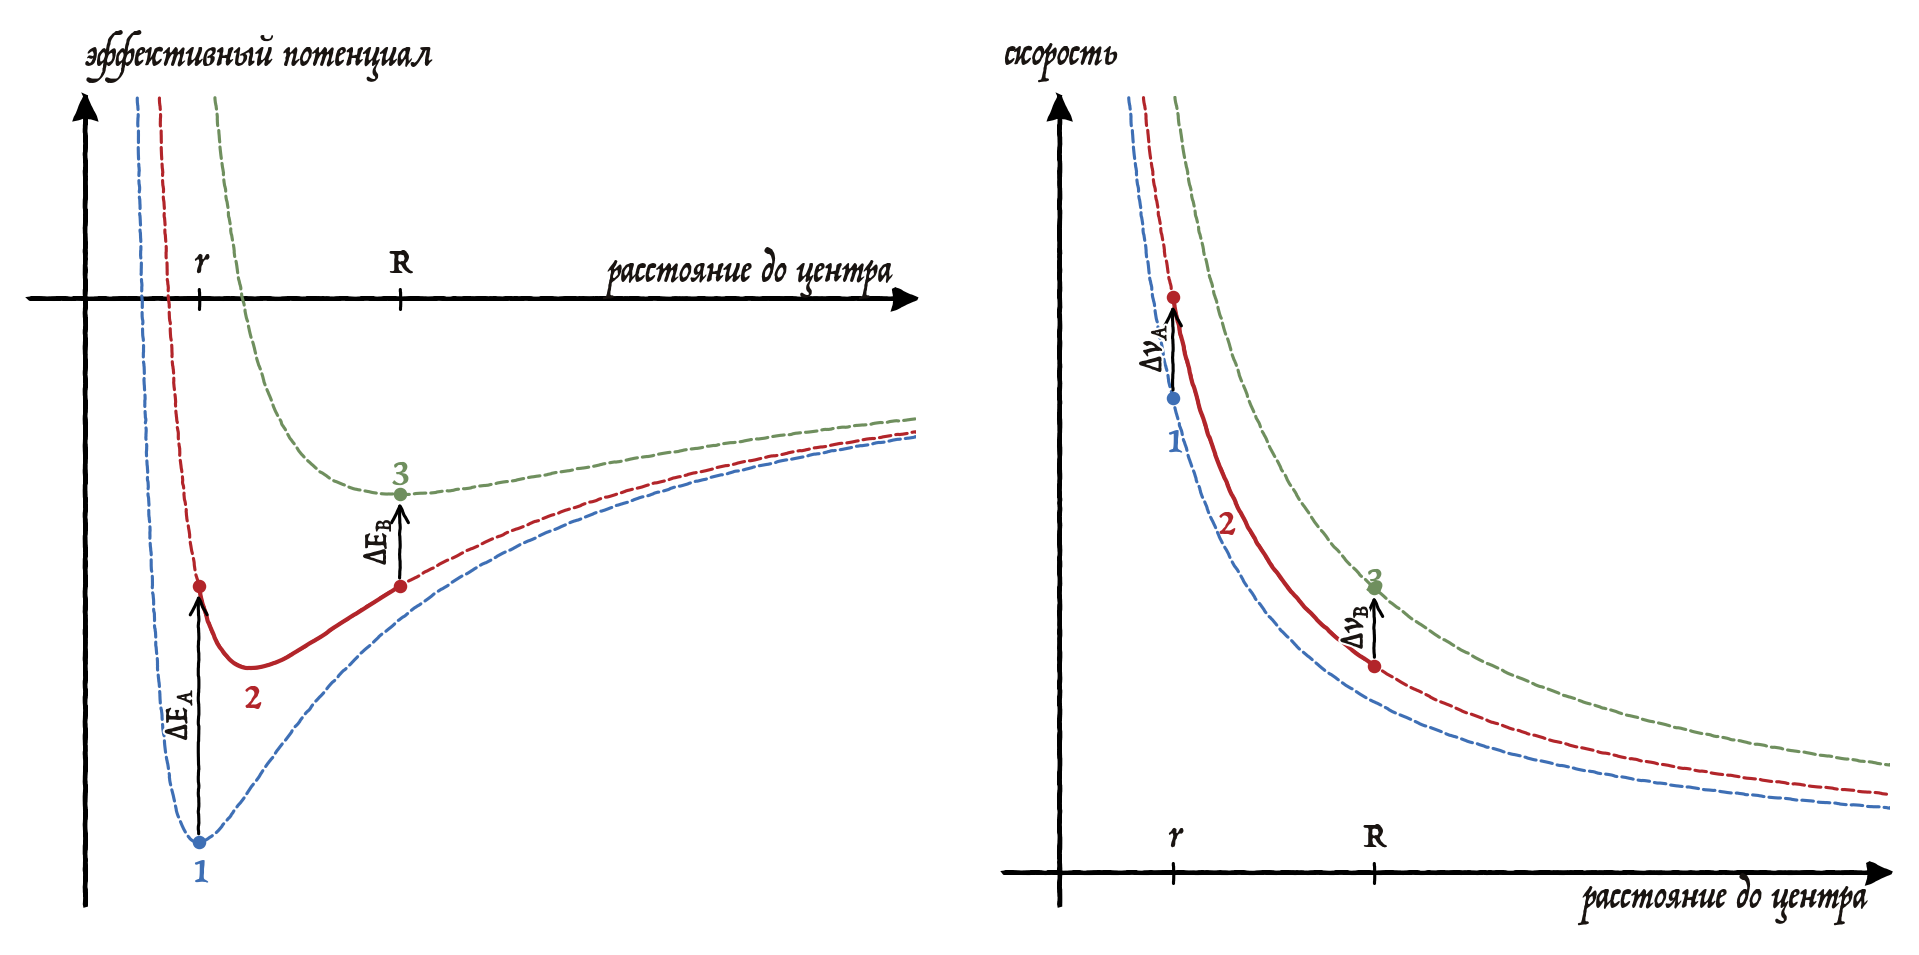

In [5]:
# @title Рис. 2 { vertical-output: true}


class Scratch:
    r = r_from_L(Parameters.Orbit.L1)
    R = r_from_L(Parameters.Orbit.L3)


def draw_hohmann_curves(ax, rs, value, show_labels=False):
    L2 = L_from_rmin_rmax(Scratch.r, Scratch.R)
    rm = r_from_L(L2)
    trajectories = [
        (
            Parameters.Orbit.L1,
            Parameters.Common.C0,
            [(Scratch.r, value(Scratch.r, Parameters.Orbit.L1))],
            None,
        ),
        (
            L2,
            Parameters.Common.C1,
            [(Scratch.r, value(Scratch.r, L2)), (Scratch.R, value(Scratch.R, L2))],
            (Scratch.r, Scratch.R),
        ),
        (
            Parameters.Orbit.L3,
            Parameters.Common.C2,
            [(Scratch.R, value(Scratch.R, Parameters.Orbit.L3))],
            None,
        ),
    ]

    for ll, col, points, solid_range in trajectories:
        ax.plot(rs, value(rs, ll), c=col, lw=0.75, ls="--")
        if solid_range is not None:
            rr = rs[(solid_range[0] < rs) & (rs <= solid_range[1])]
            ax.plot(rr, value(rr, ll), c=col, lw=1, ls="-")
        ax.scatter(
            [point[0] for point in points], [point[1] for point in points], c=col, s=5
        )

    if show_labels:
        ax.text(
            Scratch.r,
            value(Scratch.r, Parameters.Orbit.L1) - 0.3,
            "1",
            ha="center",
            va="top",
            c=Parameters.Common.C0,
        )
        ax.text(
            rm, value(rm, L2) - 0.3, "2", ha="center", va="top", c=Parameters.Common.C1
        )
        ax.text(
            Scratch.R,
            value(Scratch.R, Parameters.Orbit.L3) - 0.3,
            "3",
            ha="center",
            va="bottom",
            c=Parameters.Common.C2,
        )


def draw_energy_arrows(ax):
    L2 = L_from_rmin_rmax(Scratch.r, Scratch.R)
    ax.annotate(
        "",
        xy=(Scratch.r, U(Scratch.r, Parameters.Orbit.L1)),
        xytext=(Scratch.r, U(Scratch.r, L2)),
        arrowprops=dict(arrowstyle="<-", lw=0.75, color="k"),
    )
    ax.text(
        Scratch.r + 0.01,
        (U(Scratch.r, Parameters.Orbit.L1) + U(Scratch.r, L2)) / 2,
        r"$\Delta E_A$",
        ha="right",
        va="center",
        rotation=90,
        path_effects=[mpatheffects.withStroke(linewidth=1, foreground="w")],
    )
    ax.annotate(
        "",
        xy=(Scratch.R, U(Scratch.R, L2)),
        xytext=(Scratch.R, U(Scratch.R, Parameters.Orbit.L3)),
        arrowprops=dict(arrowstyle="<-", lw=0.75, color="k"),
    )
    ax.text(
        Scratch.R + 0.01,
        (U(Scratch.R, L2) + U(Scratch.R, Parameters.Orbit.L3)) / 2,
        r"$\Delta E_B$",
        ha="right",
        va="center",
        rotation=90,
    )


def draw_velocity_arrows(ax):
    L2 = L_from_rmin_rmax(Scratch.r, Scratch.R)
    ax.annotate(
        "",
        xy=(Scratch.r, V(Scratch.r, Parameters.Orbit.L1)),
        xytext=(Scratch.r, V(Scratch.r, L2)),
        arrowprops=dict(arrowstyle="<-", lw=0.75, color="k"),
    )
    ax.text(
        Scratch.r + 0.01,
        (V(Scratch.r, Parameters.Orbit.L1) + V(Scratch.r, L2)) / 2,
        r"$\Delta v_A$",
        ha="right",
        va="center",
        rotation=90,
        path_effects=[mpatheffects.withStroke(linewidth=1, foreground="w")],
    )
    ax.annotate(
        "",
        xy=(Scratch.R, V(Scratch.R, L2)),
        xytext=(Scratch.R, V(Scratch.R, Parameters.Orbit.L3)),
        arrowprops=dict(arrowstyle="<-", lw=0.75, color="k"),
    )
    ax.text(
        Scratch.R + 0.01,
        (V(Scratch.R, L2) + V(Scratch.R, Parameters.Orbit.L3)) / 2,
        r"$\Delta v_B$",
        ha="right",
        va="center",
        rotation=90,
        path_effects=[mpatheffects.withStroke(linewidth=1, foreground="w")],
    )


def decorate_axis(fig, ax, xlim, ylim, x_label_va, y_label, y_label_ha):
    ax.set(xlim=xlim, ylim=ylim)
    plt.sca(ax)
    arrowed_spines(fig, ax)
    yscale = (ylim[1] - ylim[0]) / 40
    ax.plot([Scratch.r, Scratch.r], [-0.5 * yscale, 0.5 * yscale], c="k", lw=0.75)
    ax.text(Scratch.r, 0.5 * yscale, "r", ha="center", va="bottom")
    ax.plot([Scratch.R, Scratch.R], [-0.5 * yscale, 0.5 * yscale], c="k", lw=0.75)
    ax.text(Scratch.R, 0.5 * yscale, "R", ha="center", va="bottom")
    ax.text(1.2, 0, "расстояние до центра", ha="center", va=x_label_va)
    ax.text(0.0, ylim[1] + 2 * yscale, y_label, ha=y_label_ha, va="center")


rs = np.linspace(0.02, 1.5, 500)

fig = plt.figure(figsize=(8, 3.5), dpi=300)
gs = fig.add_gridspec(1, 2, wspace=0.1)
ax_u = fig.add_subplot(gs[0, 0])
ax_v = fig.add_subplot(gs[0, 1])

draw_hohmann_curves(ax_u, rs, U, show_labels=True)
draw_energy_arrows(ax_u)
draw_hohmann_curves(ax_v, rs, V, show_labels=True)
draw_velocity_arrows(ax_v)

decorate_axis(
    fig,
    ax_u,
    xlim=(-0.1, 1.5),
    ylim=(-30, 10),
    x_label_va="bottom",
    y_label="эффективный потенциал",
    y_label_ha="left",
)
decorate_axis(
    fig,
    ax_v,
    xlim=(-0.1, 1.5),
    ylim=(-0.5, 12),
    x_label_va="top",
    y_label="скорость",
    y_label_ha="center",
);

Рис. 2: Слева: эффективный потенциал орбит в зависимости от расстояния до центра для трёх траекторий. Минимумы каждого из потенциалов соответствуют круговым траекториям. Движение по эллиптической траектории соответствует линии вдоль кривой потенциала между ближайшей и самой далёкой точками: $r$ и $R$. Справа: соответствующие значения скорости корабля.

## Подсказка #1

Нужно иметь ввиду, что после каждого этапа манёвра, масса корабля меняется. Согласно формуле Циолковского, изменение скорости корабля напрямую связано с изменением её массы:

$$
\Delta v = v_0 \log{\frac{m+\Delta m}{m}},
$$

где $v_0$ скорость истечения топливо относительно корабля, $\Delta m$, количество израсходованного топлива.

## Подсказка #2

Не смотря на то, что изменение энергии при любом манёвре от круговой орбиты $r$ до $R$ всегда будет одинаково, с точки зрения экономии топлива, нам важно не изменение энергии, а изменение скорости корабля (см. формулу Циолковского).

# Решение

Разберёмся сперва с задачей про гомановский манёвр.

Обозначим за $v_1 \equiv v_\oplus = \sqrt{GM/r}$ и $v_3 = \sqrt{GM/R} = v_\oplus\sqrt{r/R}$ скорости круговых орбит в начальной и финальной стадии.

> Формулу для скорости на круговой траектории можно найти, приравняв центростремительное ускорение $mv^2 / r$ к гравитационной силе притяжения центрального объекта $GMm/r^2$.

Скорости на эллиптической траектории #2, обозначим соответственно $v_{2;r}$ и $v_{2;R}$. Закон сохранения момента импульса на траектории #2 гласит, что

$$
\mathcal{L}_2 = m_2 v_{2;r} r = m_2 v_{2;R} R,
$$

а закон сохранения энергии:

$$
\mathcal{E}_2 = \frac{1}{2}m_2 v_{2;r}^2 - \frac{G M m_2}{r} = \frac{1}{2}m_2 v_{2;R}^2 - \frac{G M m_2}{R},
$$

где $m_2$ -- это масса корабля во время движения по траектории #2.

Формула Циолковского также гласит, что при идеальном манёвре без потерь, изменение массы корабля напрямую связано с изменением скорости движения корабля (в точках $A$ и $B$ соответственно):

$$
\begin{aligned}
\Delta v_A \equiv v_{2;r} - v_1 &= v_0\log{\frac{m_1}{m_2}},\\
\Delta v_B \equiv v_3 - v_{2;R} &= v_0\log{\frac{m_2}{m_3}}.
\end{aligned}
$$

Таким образом, мы получаем 4 уравнения с 4 неизвестными -- $v_{2;r}$, $v_{2;R}$, $m_2 / m_1$, $m_3 / m_1$. Решив эту систему и подставив значения для $v_1$ и $v_3$, получим (взяв $x\equiv r/R\leq 1$):

$$
\frac{m_1}{m_3} = \exp{\left[\frac{v_\oplus}{v_0}\left(\sqrt{2}\frac{1-x}{\sqrt{1+x}}+\sqrt{x}-1\right)\right]}.
$$

Для значений $\Delta v$ в точках $A$ и $B$ получим:

$$
\begin{aligned}
\Delta v_A &= v_\oplus\left(\frac{\sqrt{2}}{\sqrt{1+x}} - 1\right),\\
\Delta v_B &= v_\oplus \left(\sqrt{x}-\frac{\sqrt{2}x}{\sqrt{1+x}}\right).
\end{aligned}
$$

График на Рис. 3 демонстрирует зависимость доли израсходованного топлива, $m_1 - m_3 / m_1$, от радиуса финальной орбиты, $R/r$. В качестве $v_\oplus$ принято значение для первой космической скорости Земли, $7.5$ км/с, а также $v_0\approx 4$ км/с. Примечательно, что зависимость резко возрастает до почти постоянного значения, после чего доля необходимого топлива убывает. Иными словами, существует самая "неэффективная" с точки зрения потребления топлива финальная орбита -- $R/r=\left(4\cos{\frac{2\pi}{9}}-3\right)^{-1}\approx 15.6$, что для Земли соответствует примерно $R\approx 10^5$ км. Парадоксально, выход на более высокие орбиты, скажем на орбиту Луны, которая находится примерно в $3.5$ раза дальше, потребует почти на $10\%$ меньше топлива.

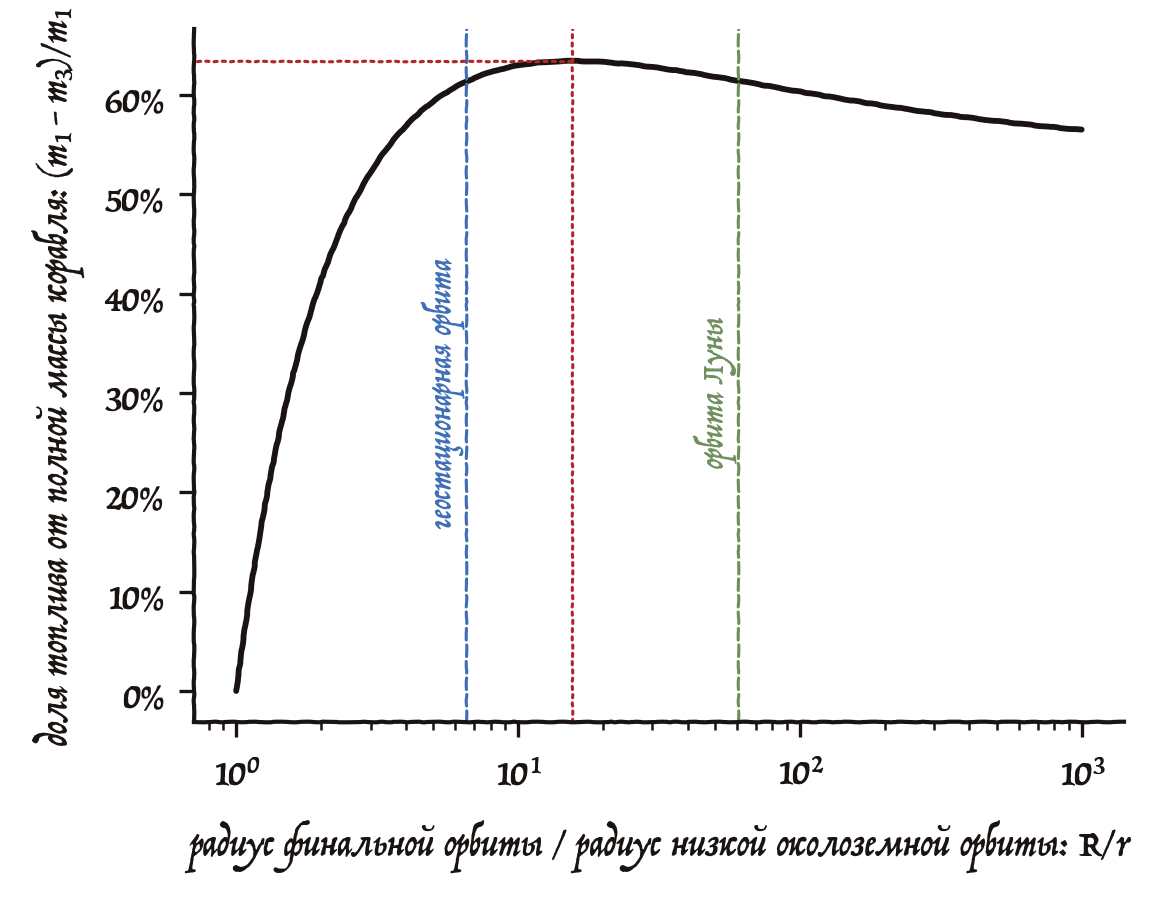

In [6]:
# @title Рис. 3 { vertical-output: true}


def check_and_plot_solution():
    v2R, v2r, R, m3, m1, m2, v1, vo, ve, x = sp.symbols(
        r"v_{2;R} v_{2;r} R m_3 m_1 m_2 v_1 v_\oplus v_e x",
        real=True,
        positive=True,
    )
    r = x * R

    GM = r * vo**2
    v1 = sp.sqrt(GM / r)
    v3 = sp.sqrt(GM / R)

    l2_lhs = v2r * r
    l2_rhs = v2R * R

    e2_lhs = v2r**2 / 2 - GM / r
    e2_rhs = v2R**2 / 2 - GM / R

    delta_v_A_lhs = v2r - v1
    delta_v_A_rhs = ve * sp.log(m1 / m2)

    delta_v_B_lhs = v3 - v2R
    delta_v_B_rhs = ve * sp.log(m2 / m3)

    equations = (
        l2_lhs - l2_rhs,
        e2_lhs - e2_rhs,
        delta_v_A_lhs - delta_v_A_rhs,
        delta_v_B_lhs - delta_v_B_rhs,
    )
    sol = sp.solve(equations, (m1, m2, v2R, v2r), dict=True)

    simplified_m1_ovr_m3 = sp.sqrt(x) + sp.sqrt(2) * (1 - x) / sp.sqrt(1 + x) - 1

    assert (
        (sp.log(sol[0][m1] / m3) * ve / vo) - simplified_m1_ovr_m3
    ).simplify() == 0, "failed"

    log_m1_ovr_m3 = sp.lambdify(x, sp.log(sol[0][m1] / m3) * ve / vo, modules=["numpy"])

    fig = plt.figure(figsize=(4, 3), dpi=300)
    ax = fig.add_subplot(111)

    def func(R_ovr_r, vplus_ovr_v0):
        m1_ovr_m3 = np.exp(vplus_ovr_v0 * log_m1_ovr_m3(1 / R_ovr_r))
        return (m1_ovr_m3 - 1) / m1_ovr_m3

    vplus_ovr_v0 = 7.5 / 4

    R_ovr_r = np.logspace(0, 3, 100)
    ax.plot(R_ovr_r, func(R_ovr_r, vplus_ovr_v0) * 100)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
    ax.axvline(x=42000 / 6400, color=Parameters.Common.C0, ls="--", lw=0.75)
    ax.axvline(x=385000 / 6400, color=Parameters.Common.C2, ls="--", lw=0.75)
    xmax = 4 * np.cos(2 * np.pi / 9) - 3
    fuel_ovr_m3_xmax = func(1 / xmax, vplus_ovr_v0) * 100
    ax.plot(
        [ax.get_xlim()[0], 1 / xmax],
        [fuel_ovr_m3_xmax, fuel_ovr_m3_xmax],
        c=Parameters.Common.C1,
        ls=":",
        lw=0.75,
    )
    ax.axvline(
        1 / xmax,
        c=Parameters.Common.C1,
        ls=":",
        lw=0.75,
    )
    ax.text(
        42000 / 6400,
        30,
        "геостационарная орбита",
        rotation=90,
        va="center",
        ha="right",
        fontsize="small",
        c=Parameters.Common.C0,
    )
    ax.text(
        385000 / 6400,
        30,
        "орбита Луны",
        rotation=90,
        va="center",
        ha="right",
        fontsize="small",
        c=Parameters.Common.C2,
    )
    ax.set(
        xscale="log",
        xlabel="радиус финальной орбиты / радиус низкой околоземной орбиты: R/r",
        ylabel="доля топлива от полной массы корабля: $(m_1-m_3)/m_1$",
    )


check_and_plot_solution()

Рис. 3: Зависимость требуемой доли топлива от полной массы корабля на низкой околоземной орбите, $(m_1 - m_3) / m_1$, от радиса финальной орбиты, $R$, для значений $v_\oplus\approx 7.5$ км/с и $v_0\approx 4$ км/с. На графике вертикальными линиями также показаны радиусы геостационарной орбиты и орбиты Луны (приняв $r=R_\oplus=6400$ км).

На Рис. 2 справа мы не случайно показали гомановскую траекторию на графике для скорости корабля. Как было указано в подсказке, и как следует из формулы Циолковского, с точки зрения экономии топлива важно не изменение полной энергии корабля во время манёвров (которое для заданных $r$ и $R$ всегда одинаково), а суммарное изменение скорости.

Рассмотрим, к примеру, серию из $n$ манёвров с переходами на различные произвольные траектории, в результате каждого из которых корабль, выпуская топливо, меняет свою массу от $m_i$ до $m_{i+1}$ ($m_{i+1} < m_i$). Соответсвующее изменение скорости при $i$-ом манёвре можно записать:

$$
\Delta v_i = v_0\log{\frac{m_i}{m_{i+1}}}.
$$

Сумма всех изменений скорости при $n$ манёврах запишется:

$$
\sum\limits_{i=1}^n\Delta v_i = v_0\sum\limits_{i=1}^n\log{\frac{m_i}{m_{i+1}}} = v_0 \log{\frac{m_1}{m_n}},
$$

где мы воспользовались свойством логарифма: $\log{a}+\log{b} = \log{ab}$. Величина $m_1/m_n$ как раз соответсвует отношению начальной массы корабля (с полным баком топлива) к финальной. Иными словами, минимизация полного расхода топлива сводится к минимизации суммарного изменения скорости при всех манёврах $\sum_i\Delta v_i$.

> Заметим, что величина $\Delta v_i$ всегда положительна по определению ($m_i > m_{i+1}$), однако это не значит, что скорость корабля всегда должна возрастать. Эту величину нужно интерпретировать как модуль изменения скорости против направления двигателя, а не против движения корабля; если направить двигатель противоположно движению корабля, то скорость корабля (в системе отсчёта Земли) может в результате манёвра уменьшиться.

Более эффективной стратегией с точки зрения затраты топлива являются, к примеру, биэллиптические манёвры, показанные на Рис. 4 (впервые идея была опубликована Ари Стернфельдом в 1930-х). Такой манёвр состоит из трёх этапов работы двигателя (в точках $A$, $B$ и $C$) с использованием двух промежуточных эллиптических орбит #2 (красным) и #3 (фиолетовым), где самая далёкая точка $B$ траектории находится на расстоянии $\rho>R$.

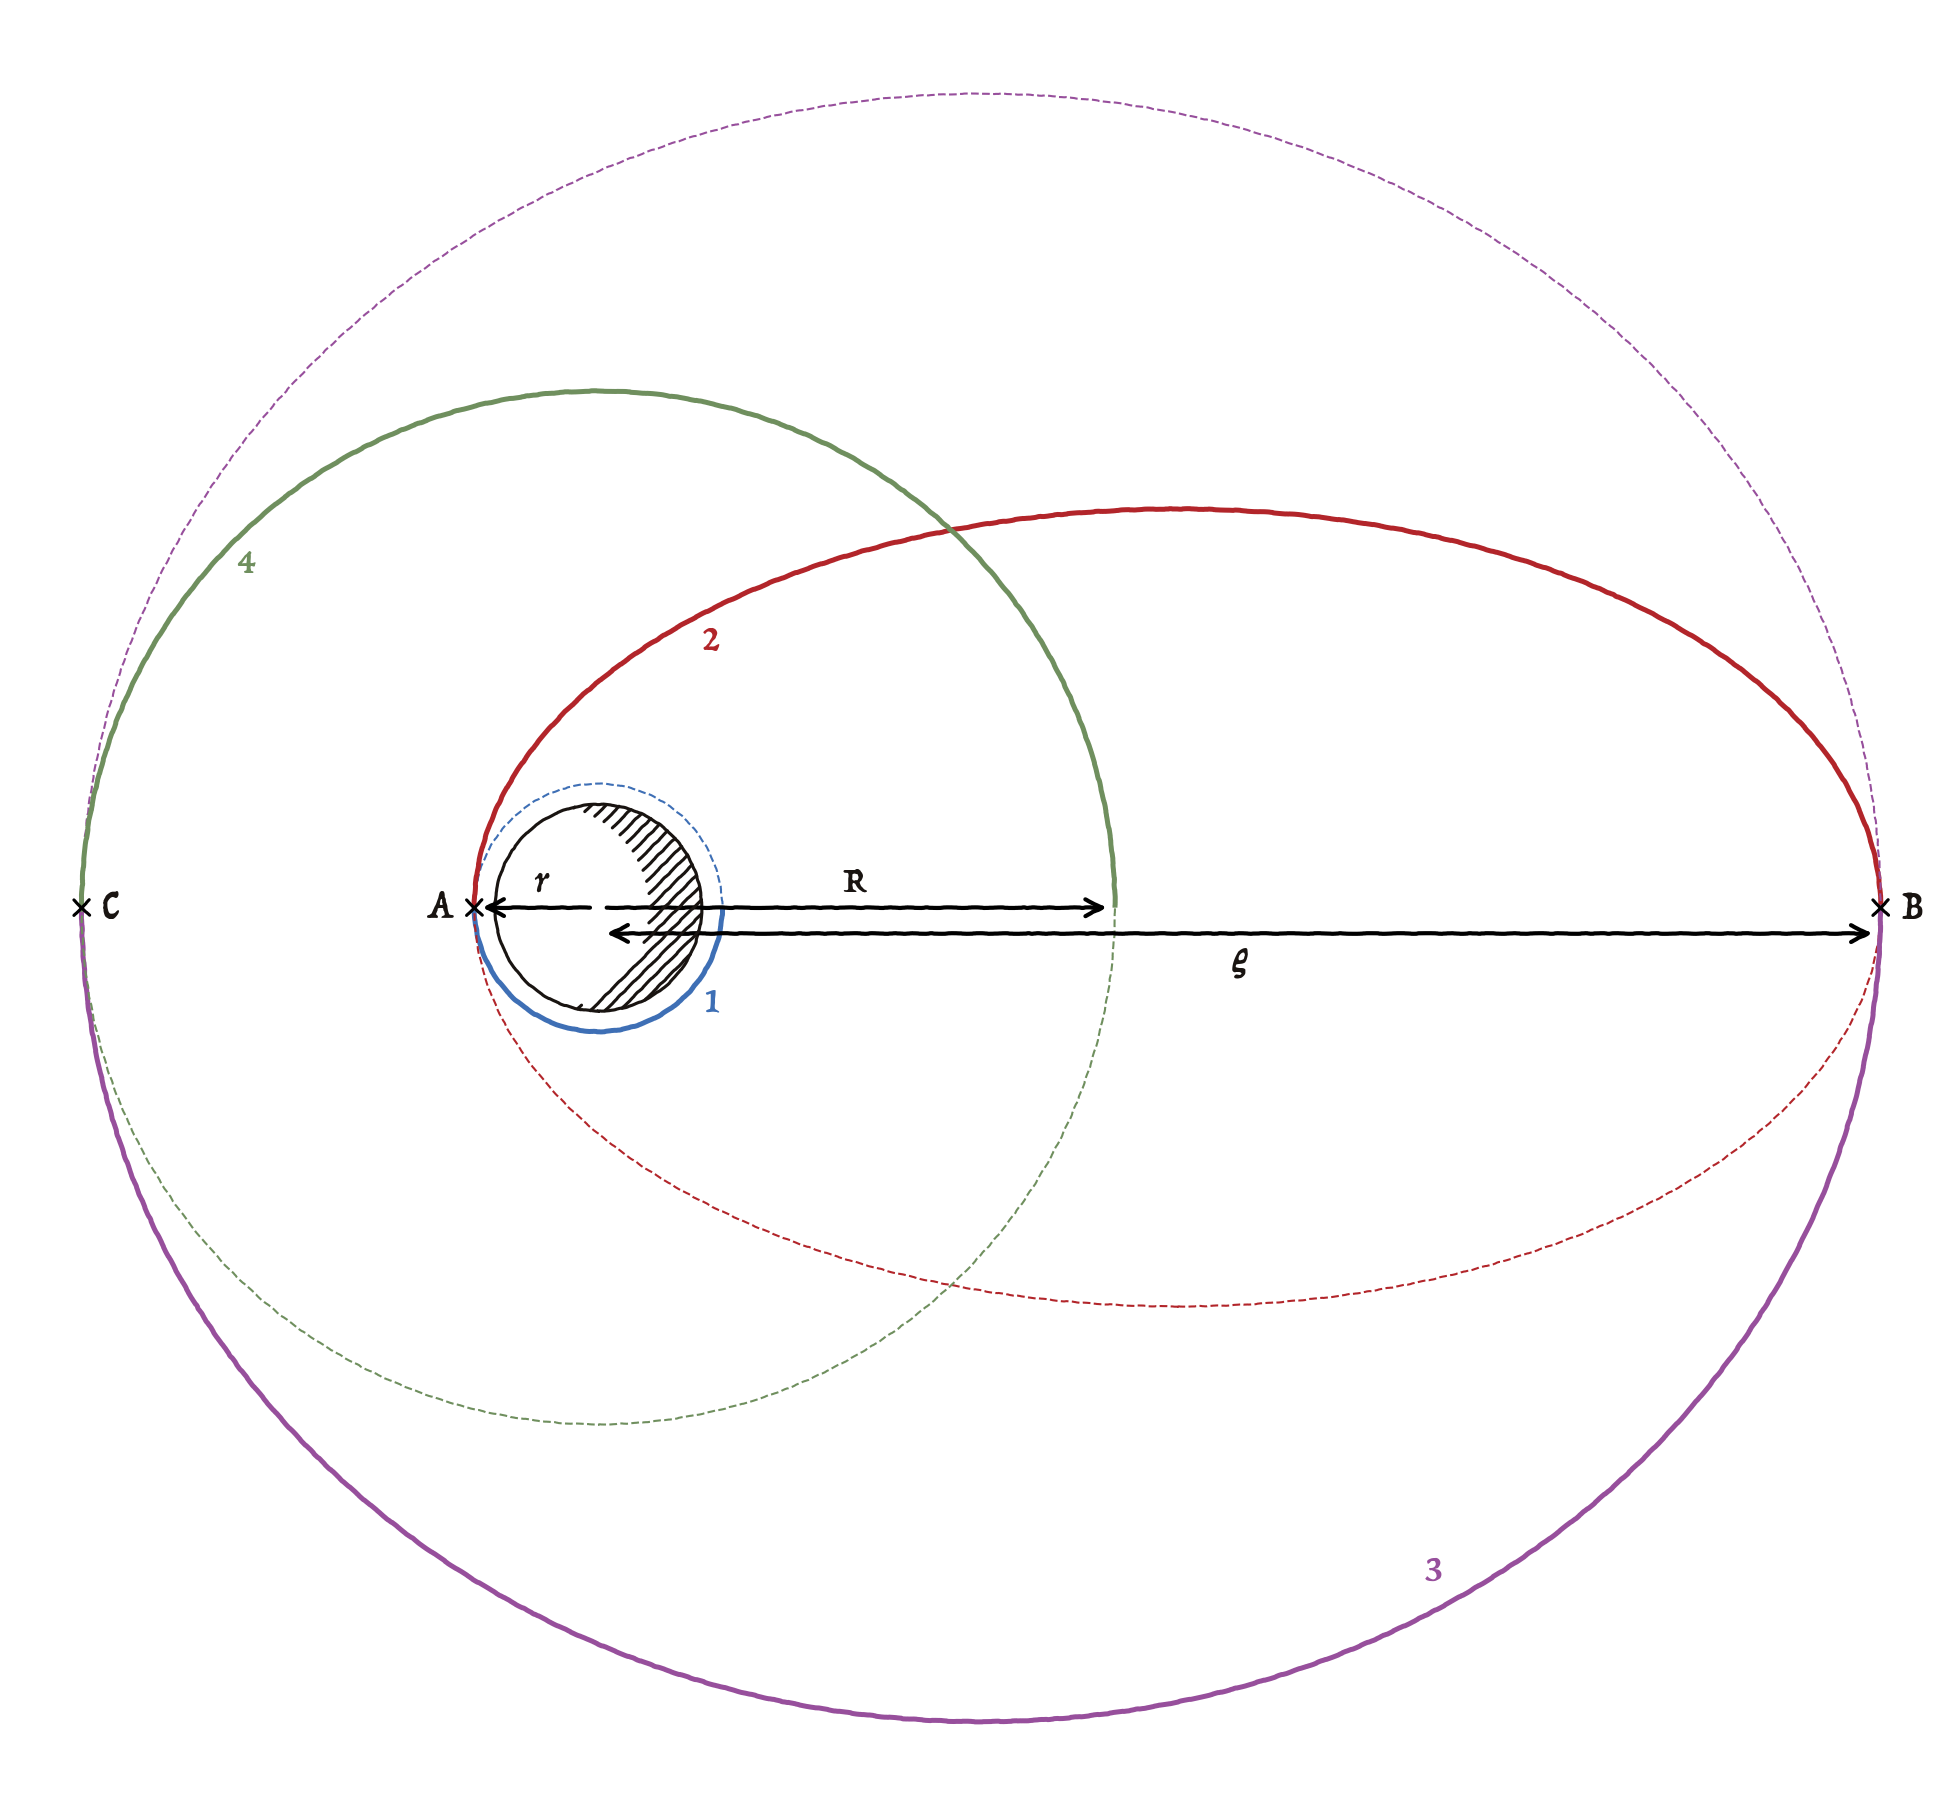

In [7]:
# @title Рис. 4 { vertical-output: true}


class Scratch1:
    ri = Parameters.Orbit.L1**2 / Parameters.Orbit.GM
    Ri = Parameters.Orbit.L3**2 / Parameters.Orbit.GM


class Scratch2:
    L2 = np.linspace(Parameters.Orbit.L1, Lmax(Scratch1.ri) * 0.98, 7)[-2]


class Scratch3:
    rmin2 = Parameters.Orbit.r
    rmax2 = Rmax(Scratch1.ri, Scratch2.L2) * Parameters.Orbit.R / Scratch1.Ri


class Scratch4:
    a2 = (Scratch3.rmin2 + Scratch3.rmax2) / 2
    b2 = np.sqrt(Scratch3.rmin2 * Scratch3.rmax2)
    rmin3 = Parameters.Orbit.R
    rmax3 = Scratch3.rmax2


class Scratch5:
    a3 = (Scratch4.rmin3 + Scratch4.rmax3) / 2
    b3 = np.sqrt(Scratch4.rmin3 * Scratch4.rmax3)


fig = plt.figure(figsize=(8, 8), dpi=300)
ax = fig.add_subplot(111)

myplt.hatchedCircle(
    ax,
    (0, 0),
    Parameters.Orbit.r0,
    shade_from=180,
    shade_depth=0.5,
    spacing=0.1,
    linewidth=0.75,
)
ax.add_artist(
    mpatches.Circle(
        (0, 0),
        Parameters.Orbit.r,
        fill=False,
        color=Parameters.Common.C0,
        linewidth=0.5,
        ls="--",
    )
)
ax.add_artist(
    mpatches.Arc(
        (0, 0),
        Parameters.Orbit.r * 2,
        Parameters.Orbit.r * 2,
        theta1=180,
        theta2=0,
        color=Parameters.Common.C0,
        linewidth=1.2,
        ls="-",
    )
)
ax.add_artist(
    mpatches.Ellipse(
        (
            -Scratch3.rmin2 + Scratch4.a2,
            0,
        ),
        Scratch4.a2 * 2,
        Scratch4.b2 * 2,
        fill=False,
        color=Parameters.Common.C1,
        linewidth=0.5,
        ls="--",
    )
)
ax.add_artist(
    mpatches.Arc(
        (
            -Scratch3.rmin2 + Scratch4.a2,
            0,
        ),
        Scratch4.a2 * 2,
        Scratch4.b2 * 2,
        theta1=0,
        theta2=180,
        color=Parameters.Common.C1,
        linewidth=1.2,
        ls="-",
    )
)
ax.add_artist(
    mpatches.Ellipse(
        (
            -Scratch4.rmin3 + Scratch5.a3,
            0,
        ),
        Scratch5.a3 * 2,
        Scratch5.b3 * 2,
        fill=False,
        color=Parameters.Common.C4,
        linewidth=0.5,
        ls="--",
    )
)
ax.add_artist(
    mpatches.Arc(
        (
            -Scratch4.rmin3 + Scratch5.a3,
            0,
        ),
        Scratch5.a3 * 2,
        Scratch5.b3 * 2,
        theta1=180,
        theta2=0,
        color=Parameters.Common.C4,
        linewidth=1.2,
        ls="-",
    )
)
ax.add_artist(
    mpatches.Circle(
        (0, 0),
        Parameters.Orbit.R,
        fill=False,
        color=Parameters.Common.C2,
        linewidth=0.5,
        ls="--",
    )
)
ax.add_artist(
    mpatches.Arc(
        (0, 0),
        Parameters.Orbit.R * 2,
        Parameters.Orbit.R * 2,
        theta1=0,
        theta2=180,
        color=Parameters.Common.C2,
        linewidth=1.2,
        ls="-",
    )
)

arr_r = mpatches.FancyArrowPatch(
    (0, 0),
    (-Parameters.Orbit.r, 0),
    arrowstyle="->",
    mutation_scale=10,
)
ax.add_artist(arr_r)
ax.annotate("r", (0.5, 0.5), xycoords=arr_r, ha="center", va="bottom")
arr_R = mpatches.FancyArrowPatch(
    (0, 0),
    (Parameters.Orbit.R, 0),
    arrowstyle="->",
    mutation_scale=10,
)
ax.add_artist(arr_R)
ax.annotate("R", (0.5, 0.5), xycoords=arr_R, ha="center", va="bottom")

arr_rmax2 = mpatches.FancyArrowPatch(
    (0, -0.25),
    (Scratch3.rmax2, -0.25),
    arrowstyle="<->",
    mutation_scale=10,
)
ax.add_artist(arr_rmax2)
ax.annotate(r"$\rho$", (0.5, 0.5), xycoords=arr_rmax2, ha="center", va="top")

ax.text(-Parameters.Orbit.r - 0.2, 0, "A", ha="right", va="center", fontsize="large")
ax.text(Scratch3.rmax2 + 0.2, 0, "B", ha="left", va="center", fontsize="large")
ax.text(-Scratch4.rmin3 + 0.2, 0, "C", ha="left", va="center", fontsize="large")
xmark(ax, -Parameters.Orbit.r, 0, 0.075, c="k", lw=0.75, ls="-")
xmark(ax, Scratch3.rmax2, 0, 0.075, c="k", lw=0.75, ls="-")
xmark(ax, -Scratch4.rmin3, 0, 0.075, c="k", lw=0.75, ls="-")

ax.text(1, -1, "1", c=Parameters.Common.C0)
ax.text(1, 2.5, "2", c=Parameters.Common.C1)
ax.text(8, -6.5, "3", c=Parameters.Common.C4)
ax.text(-3.5, 3.25, "4", c=Parameters.Common.C2)

ax.set(xlim=(-5.5, 12.5), ylim=(-8.5, 8.5), aspect=1)
ax.axis("off");

Рис. 4: Биэллиптический манёвр от искомой круговой траектории #1 до более далёкой #4.

Биэллиптическая траектория на графиках эффективного потенциала и скорости от расстояние показана на Рис. 5. Заметим, что манёвр в точке $B$ на расстоянии $\rho$ меняет скорост на очень малую величину (чем дальше $\rho$, тем меньше эта величина). В точке $C$, корабль должен включить двигатели противоположно скорости движения, чтобы замедлиться до круговой орбиты #4.

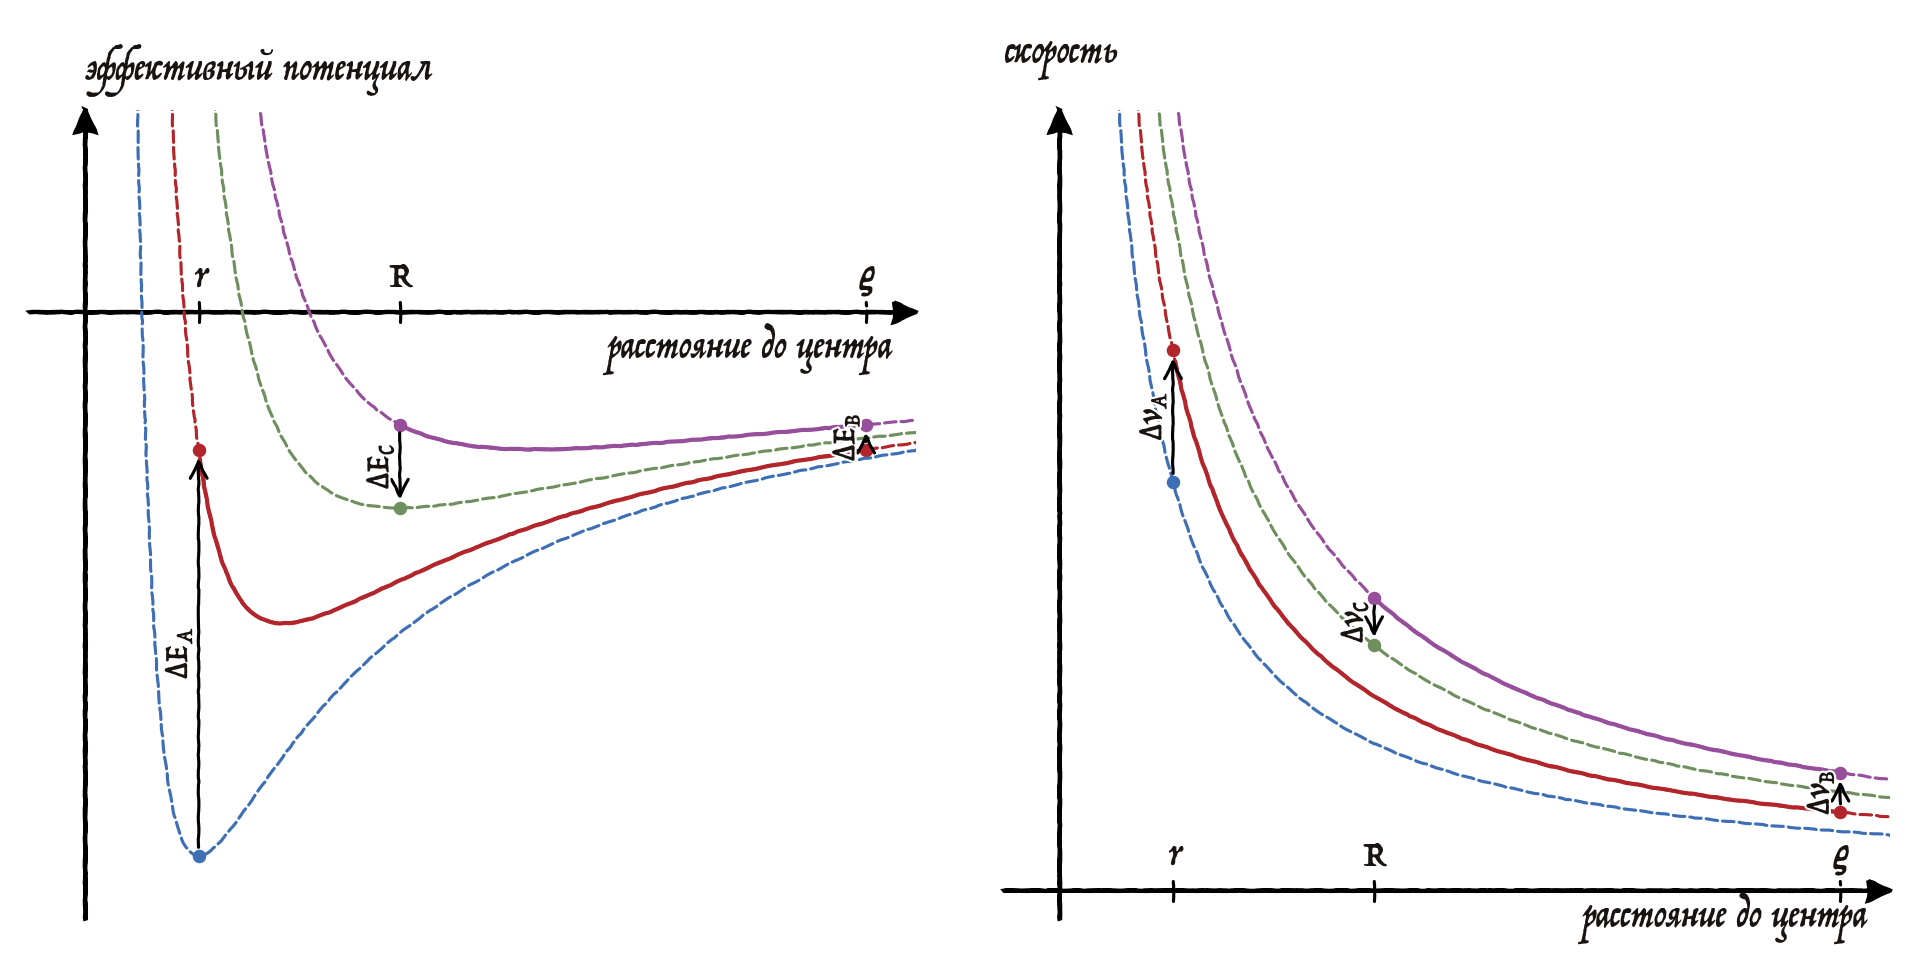

In [8]:
# @title Рис. 5 { vertical-output: true}


class Scratch1:
    r = r_from_L(Parameters.Orbit.L1)
    R = r_from_L(Parameters.Orbit.L3)


class Scratch2:
    L2 = np.linspace(Parameters.Orbit.L1, Lmax(Scratch.r) * 0.98, 7)[-2]


class Scratch3:
    rmax = Rmax(Scratch.r, Scratch2.L2)


class Scratch4:
    L3 = L_from_rmin_rmax(Scratch.R, Scratch3.rmax)


def draw_transfer_family(ax, rs, value):
    transfers = [
        (Scratch2.L2, Scratch.r, Scratch3.rmax, Parameters.Common.C1, 0.75, 1, 5),
        (Scratch4.L3, Scratch.R, Scratch3.rmax, Parameters.Common.C4, 0.75, 1, 5),
    ]
    ax.plot(
        rs, value(rs, Parameters.Orbit.L1), c=Parameters.Common.C0, lw=0.75, ls="--"
    )
    ax.scatter(
        [Scratch.r],
        [value(Scratch.r, Parameters.Orbit.L1)],
        c=Parameters.Common.C0,
        s=5,
    )

    for ll, rmin, rmax, col, lwdash, lwsolid, ms in transfers:
        ax.plot(rs, value(rs, ll), c=col, lw=lwdash, ls="--")
        rr = rs[(rmin <= rs) & (rs <= rmax)]
        ax.plot(rr, value(rr, ll), c=col, lw=lwsolid, ls="-")
        ax.scatter([rmin, rmax], [value(rmin, ll), value(rmax, ll)], c=col, s=ms)

    ax.plot(
        rs, value(rs, Parameters.Orbit.L3), c=Parameters.Common.C2, lw=0.75, ls="--"
    )
    ax.scatter(
        [Scratch.R],
        [value(Scratch.R, Parameters.Orbit.L3)],
        c=Parameters.Common.C2,
        s=5,
    )


def draw_transfer_arrow(ax, x, y_from, y_to, label):
    ax.annotate(
        "",
        xy=(x, y_from),
        xytext=(x, y_to),
        arrowprops=dict(arrowstyle="<-", lw=0.75, color="k"),
    )
    ax.text(
        x + 0.01,
        (y_from + y_to) / 2,
        label,
        ha="right",
        va="center",
        rotation=90,
        path_effects=[mpatheffects.withStroke(linewidth=1, foreground="w")],
    )


def draw_energy_arrows(ax):
    draw_transfer_arrow(
        ax,
        Scratch1.r,
        U(Scratch1.r, Parameters.Orbit.L1),
        U(Scratch1.r, Scratch2.L2),
        r"$\Delta E_A$",
    )
    draw_transfer_arrow(
        ax,
        Scratch3.rmax,
        U(Scratch3.rmax, Scratch2.L2),
        U(Scratch3.rmax, Scratch4.L3),
        r"$\Delta E_B$",
    )
    draw_transfer_arrow(
        ax,
        Scratch1.R,
        U(Scratch1.R, Scratch4.L3),
        U(Scratch1.R, Parameters.Orbit.L3),
        r"$\Delta E_C$",
    )


def draw_velocity_arrows(ax):
    draw_transfer_arrow(
        ax,
        Scratch1.r,
        V(Scratch1.r, Parameters.Orbit.L1),
        V(Scratch1.r, Scratch2.L2),
        r"$\Delta v_A$",
    )
    draw_transfer_arrow(
        ax,
        Scratch3.rmax,
        V(Scratch3.rmax, Scratch2.L2),
        V(Scratch3.rmax, Scratch4.L3),
        r"$\Delta v_B$",
    )
    draw_transfer_arrow(
        ax,
        Scratch1.R,
        V(Scratch1.R, Scratch4.L3),
        V(Scratch1.R, Parameters.Orbit.L3),
        r"$\Delta v_C$",
    )


def decorate_axis(
    fig, ax, xlim, ylim, x_label_pos, x_label_va, y_label_pos, y_label_ha, y_label
):
    ax.set(xlim=xlim, ylim=ylim)
    plt.sca(ax)
    arrowed_spines(fig, ax)
    yscale = (ylim[1] - ylim[0]) / 40
    ax.plot(
        [Scratch1.r, Scratch1.r],
        [-0.5 * yscale, 0.5 * yscale],
        c="k",
        lw=0.75,
        zorder=-1,
    )
    ax.text(Scratch1.r, 0.5 * yscale, "r", ha="center", va="bottom", zorder=-1)
    ax.plot(
        [Scratch1.R, Scratch1.R],
        [-0.5 * yscale, 0.5 * yscale],
        c="k",
        lw=0.75,
        zorder=-1,
    )
    ax.text(Scratch1.R, 0.5 * yscale, "R", ha="center", va="bottom", zorder=-1)
    ax.plot(
        [Scratch3.rmax, Scratch3.rmax],
        [-0.5 * yscale, 0.5 * yscale],
        c="k",
        lw=0.75,
        zorder=-1,
    )
    ax.text(Scratch3.rmax, 0.5 * yscale, r"$\rho$", ha="center", va="bottom", zorder=-1)
    ax.text(*x_label_pos, "расстояние до центра", ha="center", va=x_label_va)
    ax.text(*y_label_pos, y_label, ha=y_label_ha, va="center")


fig = plt.figure(figsize=(8, 3.5), dpi=300)
gs = fig.add_gridspec(1, 2, wspace=0.1)
ax_u = fig.add_subplot(gs[0, 0])
ax_v = fig.add_subplot(gs[0, 1])

draw_transfer_family(ax_v, np.linspace(0.02, 2.5, 500), V)
draw_velocity_arrows(ax_v)
draw_transfer_family(ax_u, np.linspace(0.02, 1.5, 500), U)
draw_energy_arrows(ax_u)

decorate_axis(
    fig,
    ax_v,
    xlim=(-0.1, 1.5),
    ylim=(-0.5, 14),
    x_label_pos=(1.2, 0),
    x_label_va="top",
    y_label_pos=(0.0, 15),
    y_label_ha="center",
    y_label="скорость",
)
decorate_axis(
    fig,
    ax_u,
    xlim=(-0.1, 1.5),
    ylim=(-30, 10),
    x_label_pos=(1.2, -0.5),
    x_label_va="top",
    y_label_pos=(0.0, 12),
    y_label_ha="left",
    y_label="эффективный потенциал",
);

Рис. 5: Биэллиптическая траектория, показанная на графике эффективного потенциала (слева) и графике скорости корабля (справа). Цвета орбит на Рис. 4 соответсвуют цветам кривых на этих графиках.

Найдём расход топлива при биэллиптическом манёвре.

Как и раньше, для начальной и финальной круговых траекторий имеем

$$
v_1 = \sqrt{GM/r},\; v_4 = \sqrt{GM/R}.
$$

Законы сохранения момента импульса и энергии на орбитах #2 и #3 запишутся в виде:

$$
\begin{aligned}
\frac{\mathcal{L}_2}{m_2} = v_{2;r} r &= v_{2;\rho} \rho,\\
\frac{\mathcal{E}_2}{m_2} = \frac{1}{2} v_{2;r}^2 - \frac{G M}{r} &= \frac{1}{2} v_{2;\rho}^2 - \frac{G M}{\rho},\\
\frac{\mathcal{L}_3}{m_3} =  v_{3;\rho} \rho &=  v_{3;R} R,\\
\frac{\mathcal{E}_3}{m_3} = \frac{1}{2}v_{3;\rho}^2 - \frac{G M}{\rho} &= \frac{1}{2}v_{3;R}^2 - \frac{G M}{R}.
\end{aligned}
$$

Изменения скорости при каждом из манёвров, согласно формуле Циолковского, при этом запишется в виде

$$
\begin{aligned}
\Delta v_A \equiv v_{2;r} - v_1 = v_0\log{\frac{m_1}{m_2}},\\
\Delta v_B \equiv v_{3;\rho} - v_{2;\rho} = v_0\log{\frac{m_2}{m_3}},\\
\Delta v_C \equiv v_{3;R} - v_{4} = v_0\log{\frac{m_3}{m_4}}.
\end{aligned}
$$

Таким образом, мы имеем 7 уравнений и 7 неизвестных (4 промежуточные скорости и 3 значения массы корабля).

Обозначив, как и прежде, $x\equiv r/R \leq 1$, а также $q\equiv R/\rho\leq 1$, найдём:

$$
\frac{m_1}{m_4} = \exp{\left[
    \frac{v_\oplus}{v_0}\left(
    \sqrt{2 x (1 + q)}
        + \frac{\sqrt{2} (1 - q x)}{\sqrt{1 + q x}}
        - \sqrt{x}
        - 1
\right)\right]}.
$$

Легко убедиться, что при $q=1$, ответ сводится к предыдущему значению $m_1/m_3$ для гомановской траектории. Полезно также посмотреть на изменения скорости при каждой стадии манёвра:

$$
\begin{aligned}
\Delta v_A &= v_\oplus\left(\frac{\sqrt{2}}{\sqrt{1+qx}} - 1\right),\\
\Delta v_B &= v_\oplus\left(\frac{1}{\sqrt{1+q}}- \frac{\sqrt{x}}{\sqrt{1+qx}}\right)\sqrt{2x}q,\\
\Delta v_C &= v_\oplus\left(\frac{\sqrt{2}}{\sqrt{1+q}} -1\right)\sqrt{x}.
\end{aligned}
$$

На Рис. 6 показана доля потребляемого топлива относительно начальной массы корабля, $(m_1-m_4)/m_4$, при биэллиптической траектории с $\rho=10 R$ для манёвров с различными финальными радиусами, $R/r$. Для сравнения, пунктиром также показан аналогичный расход для гомановской траектории (как на Рис. 3). Из графика видно, что биэллиптическая траектория не всегда является более оптимальной. В частности, при $R/r \lesssim 11.94$, гомановский манёвр всегда является более оптимальным. Также можно показать, что при $R/r \gtrsim 15.6$, произвольный биэллиптический манёвр с $\rho > R$ является более оптимальным; при промежуточных же значениях $R/r$, всегда можно подобрать высокую биэллиптическую орбиту $\rho > R$, при которой такая траектория окажется оптимальнее гомановской (причём, чем меньше $R/r$, тем более высокую траекторию придётся подбирать). Это обстоятельство продемонстрировано на Рис. 7, где для заданных величин $\rho/R$ и $R/r$ цветом указана какая из двух стратегий наиболее эффективна; в красной области эффективна гомановская траектория, в синей -- биэллиптическая.

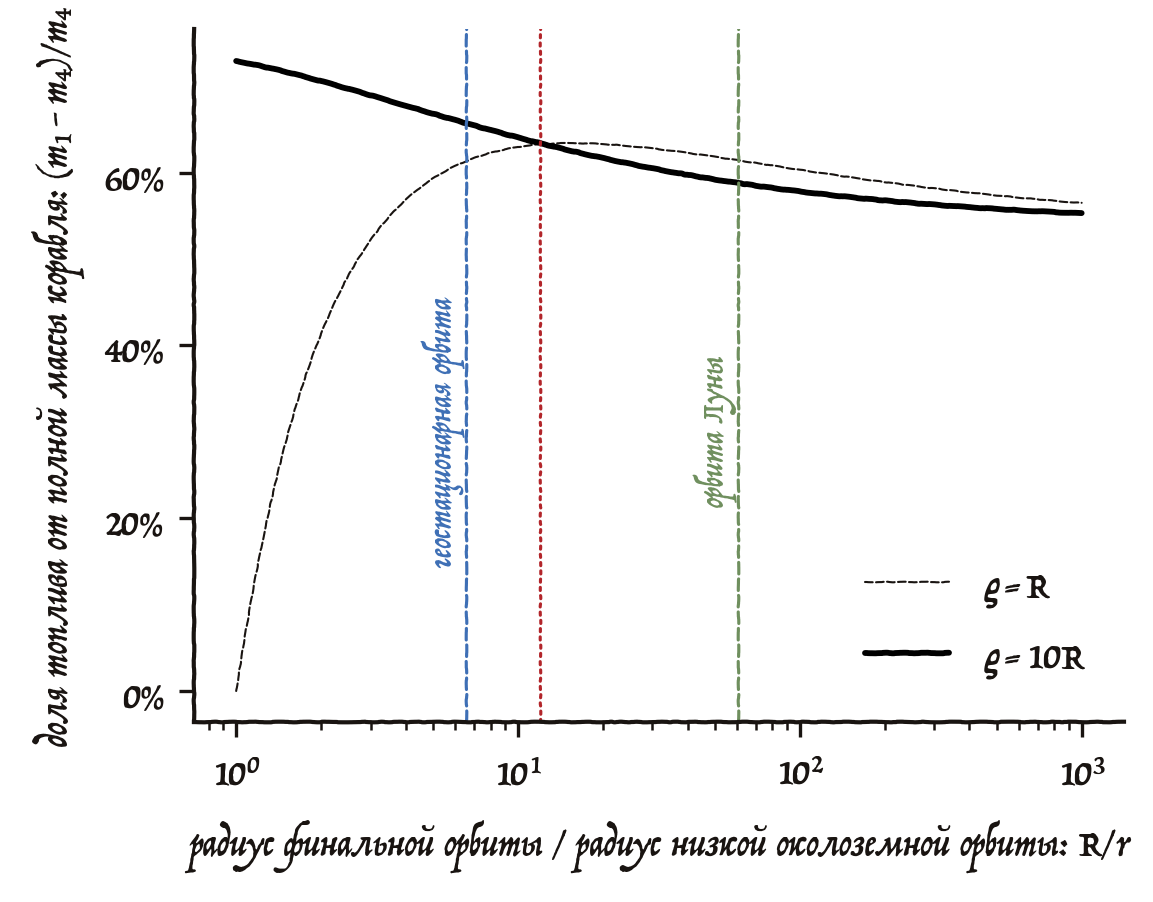

In [9]:
# @title Рис. 6 { vertical-output: true}


def bielliptic_solution():
    x = sp.symbols(r"x", real=True, positive=True)  # r / R
    q = sp.symbols(r"q", real=True, positive=True)  # R / rho
    r = sp.symbols(r"r", real=True, positive=True)  # radius of initial orbit
    R = r / x
    rho = R / q
    v2r, v2rho = sp.symbols(r"v_{2;r} v_{2;\rho}", real=True, positive=True)
    v3rho, v3R = sp.symbols(r"v_{3;\rho} v_{3;R}", real=True, positive=True)
    mu21 = sp.symbols(r"\mu_{21}", real=True, positive=True)  # m2 / m1
    mu32 = sp.symbols(r"\mu_{32}", real=True, positive=True)  # m3 / m2
    mu14 = sp.symbols(r"\mu_{14}", real=True, positive=True)  # m1 / m4
    vo = sp.symbols(r"v_\oplus", real=True, positive=True)
    v0 = sp.symbols(r"v_0", real=True, positive=True)
    GM = vo**2 * r
    v1 = vo
    v4 = sp.sqrt(GM / R)

    eqns = [
        v2r * r - v2rho * rho,
        v2r**2 - 2 * GM / r - (v2rho**2 - 2 * GM / rho),
        v3rho * rho - v3R * R,
        v3rho**2 - 2 * GM / rho - (v3R**2 - 2 * GM / R),
        v2r - v1 - v0 * sp.log(1 / mu21),
        v3rho - v2rho - v0 * sp.log(1 / mu32),
        v3R - v4 - v0 * sp.log(mu14 * mu32 * mu21),
    ]
    sol = sp.solve(eqns, (v2r, v2rho, v3rho, v3R, mu21, mu32, mu14), dict=True)

    log_mu14_v0_over_vo_simplified = (
        sp.sqrt(2 * x * (1 + q))
        + sp.sqrt(2) * (1 - q * x) / sp.sqrt(1 + q * x)
        - sp.sqrt(x)
        - 1
    )

    assert (
        (sp.log(sol[0][mu14]) * v0 / vo).simplify() - log_mu14_v0_over_vo_simplified
    ).simplify() == 0, "failed"

    log_mu14_v0_over_vo_lambdified = sp.lambdify(
        [x, q], log_mu14_v0_over_vo_simplified, modules=["numpy"]
    )

    fig = plt.figure(figsize=(4, 3), dpi=300)
    ax = fig.add_subplot(111)

    def func(R_ovr_r, rho_ovr_R, vplus_ovr_v0):
        m1_ovr_m3 = np.exp(
            vplus_ovr_v0 * log_mu14_v0_over_vo_lambdified(1 / R_ovr_r, 1 / rho_ovr_R)
        )
        return (m1_ovr_m3 - 1) / m1_ovr_m3

    vplus_ovr_v0 = 7.5 / 4

    R_ovr_r = np.logspace(0, 3, 100)
    ax.plot(
        R_ovr_r,
        func(R_ovr_r, 1, vplus_ovr_v0) * 100,
        ls="--",
        lw=0.5,
        label=r"$\rho = R$",
    )
    ax.plot(
        R_ovr_r, func(R_ovr_r, 10, vplus_ovr_v0) * 100, c="k", label=r"$\rho = 10R$"
    )
    ax.legend(loc="lower right")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
    ax.axvline(x=42000 / 6400, color=Parameters.Common.C0, ls="--", lw=0.75)
    ax.axvline(x=385000 / 6400, color=Parameters.Common.C2, ls="--", lw=0.75)
    # xmax = 4 * np.cos(2 * np.pi / 9) - 3
    # fuel_ovr_m3_xmax = func(1 / xmax, 1, vplus_ovr_v0) * 100
    # ax.plot(
    #     [ax.get_xlim()[0], 1 / xmax],
    #     [fuel_ovr_m3_xmax, fuel_ovr_m3_xmax],
    #     c=Parameters.Common.C1,
    #     ls=":",
    #     lw=0.75,
    # )
    ax.axvline(
        11.94,
        c=Parameters.Common.C1,
        ls=":",
        lw=0.75,
    )
    ax.text(
        42000 / 6400,
        30,
        "геостационарная орбита",
        rotation=90,
        va="center",
        ha="right",
        fontsize="small",
        c=Parameters.Common.C0,
    )
    ax.text(
        385000 / 6400,
        30,
        "орбита Луны",
        rotation=90,
        va="center",
        ha="right",
        fontsize="small",
        c=Parameters.Common.C2,
    )
    ax.set(
        xscale="log",
        xlabel="радиус финальной орбиты / радиус низкой околоземной орбиты: R/r",
        ylabel="доля топлива от полной массы корабля: $(m_1-m_4)/m_4$",
    )

    # display((sol[0][v2r] - v1).simplify())
    # display((sol[0][v3rho] - sol[0][v2rho]).simplify())
    # display((sol[0][v3R] - v4).simplify())


bielliptic_solution()

Рис. 6: Зависимость доли потребляемого топлива от отношения радиусов финальной и начальной орбиты, $R/r$. Для сравнения, показана гомановская траектория (чёрным пунктиром), и биэллиптическая орбита с $\rho=10R$.

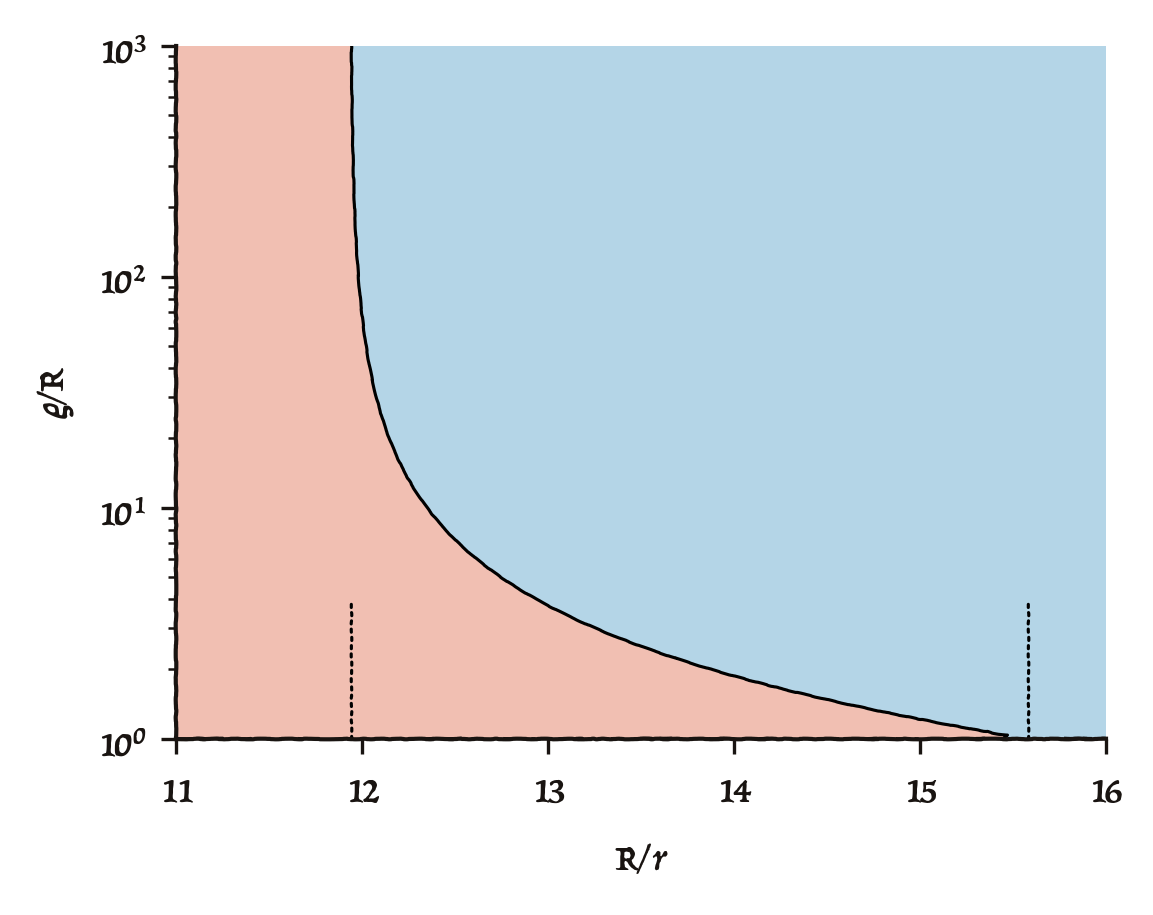

In [10]:
# @title Рис. 7 { vertical-output: true}

def func(X, Q):
    return (
        -((np.sqrt(2) * (1 - 1 / X)) / np.sqrt(1 + 1 / X))
        + (np.sqrt(2) * (1 - 1 / (Q * X))) / np.sqrt(1 + 1 / (Q * X))
        - 2 * np.sqrt(1 / X)
        + np.sqrt(2) * np.sqrt((1 + 1 / Q) / X)
    )


fig = plt.figure(figsize=(4, 3), dpi=300)
ax = fig.add_subplot(111)

Xs = np.linspace(11, 16, 200)
Qs = np.logspace(0, 3, 200)
XX, QQ = np.meshgrid(Xs, Qs)

ax.contourf(XX, QQ, func(XX, QQ), levels=[-1, 0, 1], cmap="RdBu_r", alpha=0.5)
ax.contour(XX, QQ, func(XX, QQ), levels=[0], colors="k", linewidths=0.75)
ax.axvline(x=11.94, ymax=0.2, color="k", ls=":", lw=0.75)
ax.axvline(
    x=1 / (4 * np.cos(2 * np.pi / 9) - 3),
    ymax=0.2,
    color="k",
    ls=":",
    lw=0.75,
)
ax.set(yscale="log", xlabel=r"$R/r$", ylabel=r"$\rho/R$");

Рис. 7: Области эффективности гомановской (красным) и биэллиптической (синим) траекторий для различных значений $R/r$ и $\rho / R$.

## Послесловие

При рассмотрении переходных манёвров в этой задаче, мы в основном концетрировались на оптимальности с точки зрения расхода топлива, однако опустили немаловажную деталь -- время. Биэллиптические траектории снижают требуемый расход топлива за счёт выведения корабля на далёкую дистанцию, $\rho$, с очень маленькой орбитальной скоростью и, соответственно, малым необходимым значением $\Delta v$ для корректировки орбиты. Из-за этого, однако длительность манёвра значительно увеличивается. Давайте сравним длительность гомановского манёвра (из точки $A$ в точку $B$, Рис. 1) и биэллиптической траектории (из точки $A$ в точку $C$, Рис. 4).

В случае с гомановской траекторией, ответ очень прост -- корабль долетает из точки $A$ в точку $B$ за половину орбитального периода траектории #2:

$$
t_H = \frac{\pi}{\sqrt{8GM}} (r+R)^{3/2} = \frac{ t_\oplus}{4\sqrt{2}}(1+R/r)^{3/2}.
$$

В случае с биэллиптической траекторией, длительность будет состоять из двух полупериодов траекторий #2 и #3:

$$
t_b = \frac{\pi}{\sqrt{8GM}} \left((r+\rho)^{3/2}+(R+\rho)^{3/2}\right)=\frac{ t_\oplus}{4\sqrt{2}}\left((1+\rho/r)^{3/2}+(R/r+\rho/r)^{3/2}\right).
$$

Здесь, $t_\oplus\equiv 2\pi\sqrt{r^3/GM}$ -- орбитальный период на низкой орбите $r$, что для Земли равно примерно $85$ минутам.

Значения для $t_H$ и $t_b$ в случае Земли показаны на Рис. 8, где пунктиром также отмечен переход от оптимальной траектории Гомана (слева) к оптимальной биэллиптической траектории (справа) (эта линия совпадает с границей на Рис. 7). Не смотря на достаточно скромный выигрыш в расходе топлива, биэллиптические траектории (особенно с большими значениями $\rho$) очень быстро становятся непрактичным с точки зрения продолжительности.

/tmp/ipykernel_1342/2476091320.py:66: UserWarning: The following kwargs were not used by contour: 'ls'
  ax.contour(XX, QQ, func(XX, QQ), levels=[0], colors="k", linewidths=0.75, ls=":")


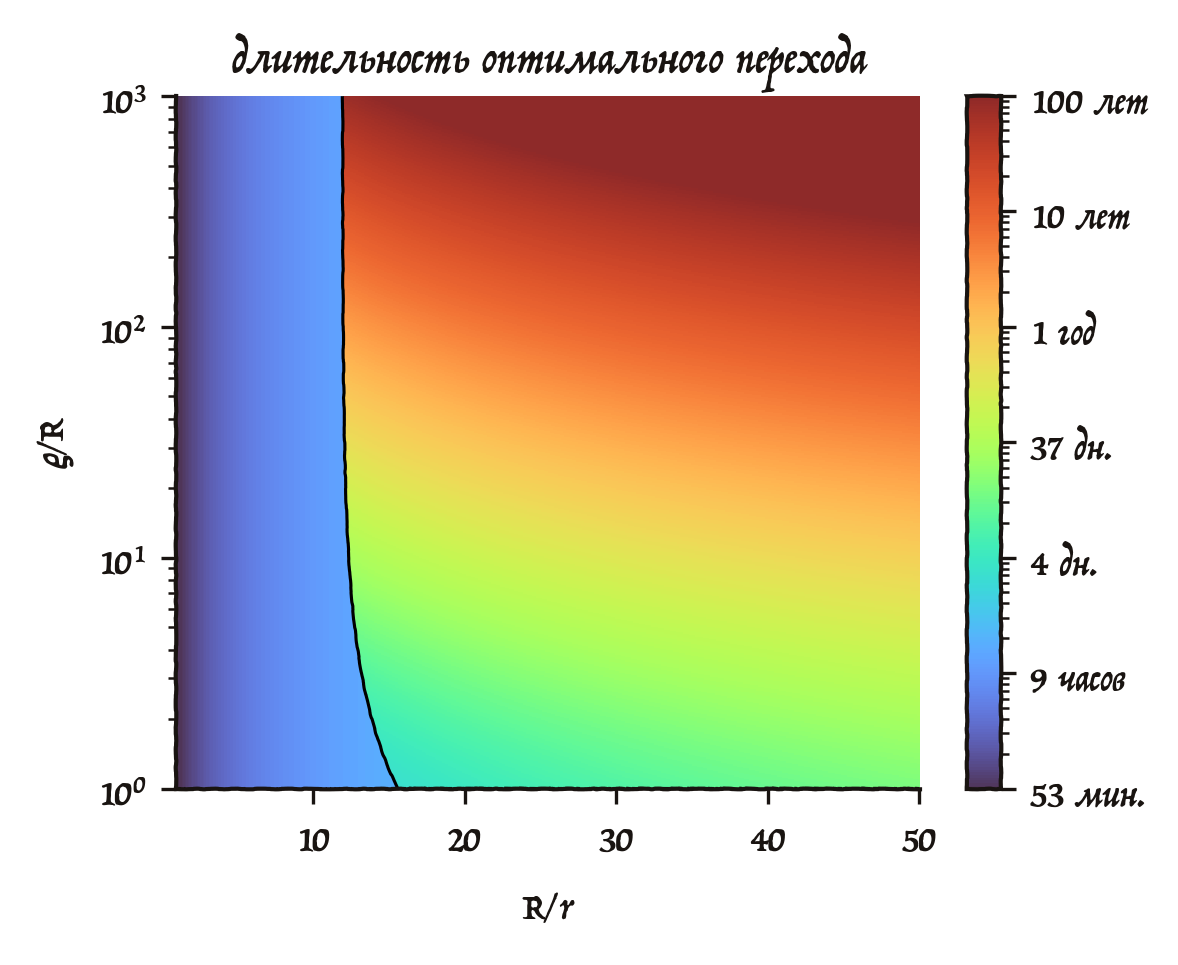

In [11]:
# @title Рис. 7 { vertical-output: true}


def t_H(x):
    min_to_year = 60 * 24 * 365.25
    R_ovr_r = 1 / x
    return (1 + R_ovr_r) ** 1.5 * 85 / (4 * np.sqrt(2)) / min_to_year


def t_b(x, q):
    min_to_year = 60 * 24 * 365.25
    R_ovr_r = 1 / x
    rho_ovr_R = 1 / q
    rho_ovr_r = rho_ovr_R * R_ovr_r
    return (
        ((1 + rho_ovr_r) ** 1.5 + (rho_ovr_r + R_ovr_r) ** 1.5)
        * 85
        / (4 * np.sqrt(2))
        / min_to_year
    )


fig = plt.figure(figsize=(4, 3), dpi=300)
ax = fig.add_subplot(111)

Xs = np.linspace(1, 50, 500)
Qs = np.logspace(0, 3, 500)
XX, QQ = np.meshgrid(Xs, Qs)

pmesh = ax.pcolormesh(
    XX,
    QQ,
    np.where(func(XX, QQ) < 0, t_b(1 / XX, 1 / QQ), t_H(1 / XX)),
    shading="auto",
    cmap="turbo",
    alpha=0.85,
    norm=mcolors.LogNorm(vmin=0.0001, vmax=1e2),
)
cbar = ax.figure.colorbar(pmesh, ax=ax)
ax.set_title("длительность оптимального перехода")


def human_readable(y, _):
    y_hr = y * 365.25 * 24
    y_min = y * 365.25 * 24 * 60
    y_day = y * 365.25
    if y_min < 60:
        return f"{y_min:.0f} мин."
    elif y_hr < 24:
        return f"{y_hr:.0f} часов"
    elif y_day < 1:
        return f"{y_day:.0f} дн."
    elif y_day < 365:
        return f"{y_day:.0f} дн."
    elif y_day < 365 * 10:
        if y < 1.5:
            return f"{y_day / 365:.0f} год"
        else:
            return f"{y_day / 365:.0f} лет"
    else:
        return f"{y_day / 365:.0f} лет"


cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(human_readable))

ax.contour(XX, QQ, func(XX, QQ), levels=[0], colors="k", linewidths=0.75)

ax.set(yscale="log", xlabel=r"$R/r$", ylabel=r"$\rho/R$");

Рис. 8: Длительность оптимального с точки зрения потребления топлива перехода от круговой орбиты радиусом $r$ до круговой орбиты радиусом $R$ с помощью гомановской (слева от пунктирной линии) и биэллиптической с промежуточной дистанцией $\rho$ (справа от пунктирной линии) траекторий.

В нашей задаче мы исключительно рассмотрели движение корабля на орбите одного массивного тела (Земли), однако в реальности эффективность и время перелётов можно значительно сократить используя другие объекты. Существует целый класс т.н. низкозатратных переходных траекторий, которые, к примеру, используют переходы через окрестности точек Лагранжа, а также гравитационные манёвры [ССЫЛКА]. При последнем, во время пролёта около планеты, аппарат меняет скорость относительно Солнца за счёт движения самой планеты по орбите. В системе отсчёта планеты энергия аппарата почти не меняется, но в гелиоцентрической системе корабль может как ускориться, так и замедлиться в зависимости от относительной скорости. Такие манёвры особенно важно для малых спутников, лунных миссий и аппаратов, которым после запуска нужно долго сохранять возможность корректировки курса, к примеру, в миссиях Voyager, Galileo, Cassini, MESSENGER и BepiColombo: без последовательности гравитационных пролётов их цели были бы недостижимы или потребовали бы намного более тяжёлых ракет.